# Stimulus-based behavior metrics from stimulus_behavior_response_df

Loads the per-mouse `stimulus_behavior_response_df` (concatenated), computes **rolling** performance
metrics and **session-average** metrics (hit rate, could-change false-alarm rate, d-prime, mean/peak
rolling d-prime, fraction engaged) using the **could_change-based false alarm rate** and the
**stimulus-based engagement state**, then plots differences across experience levels across mice,
reusing the Figure 2 plotting functions where possible.

> NOTE: the currently-saved `stimulus_behavior_response_df`s do not yet have `could_change` or the new
> stimulus-based `engagement_state` / `reward_rate`. Regenerate them (via the updated
> `get_annotated_stimulus_presentations`) before this notebook will run end-to-end. The columns are
> expected to match that function's output. A column sanity-check cell below tells you what's missing.

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import visual_behavior.utilities as vbu
from visual_behavior.data_access import loading
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

%load_ext autoreload
%autoreload 2
%matplotlib inline
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# metadata + palette (mirrors figure_2_main)
metadata_tables_dir = loading.get_metadata_tables_dir()
platform_experiments = pd.read_csv(
    os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()

# one row per behavior session: experience level / mouse / cell type
session_meta = (platform_experiments[['behavior_session_id', 'mouse_id', 'experience_level', 'cell_type']]
                .drop_duplicates('behavior_session_id'))

## Load stimulus_behavior_response_df

In [26]:
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique():
    filename = str(mouse_id) + '_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try:
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except Exception:
        problem_mice.append(mouse_id)
print(len(stim_behavior_response_df.mouse_id.unique()), 'mice loaded')
print('problem_mice:', problem_mice)

# add experience_level (and cell_type) per behavior session
stim_behavior_response_df = stim_behavior_response_df.merge(
    session_meta[['behavior_session_id', 'experience_level', 'cell_type']],
    on='behavior_session_id', how='left')

66 mice loaded
problem_mice: []


### Drop auto-rewarded warm-up period

Per session, keep only flashes **after the last auto-rewarded trial**. This removes auto-rewarded change
flashes *and* the could-change flashes during the warm-up, so every downstream metric (session-level and
rolling) is computed on the post-warm-up portion only. Assumes auto-rewards occur at the session start
(standard change-detection task). Skip this cell to keep the full session.

In [27]:
def _drop_autorewarded_period(sp):
    auto = sp[sp['auto_rewarded'] == True]
    if len(auto) == 0:
        return sp
    return sp[sp['start_time'] > auto['start_time'].max()]

# keep a copy WITH the auto-rewarded warm-up for the with/without comparison section below
stim_behavior_response_df_full = stim_behavior_response_df.copy()

_n0 = len(stim_behavior_response_df)
stim_behavior_response_df = (stim_behavior_response_df
                             .groupby('behavior_session_id', group_keys=False)
                             .apply(_drop_autorewarded_period))
print('dropped %d warm-up flashes (%d -> %d); remaining auto_rewarded flashes: %d'
      % (_n0 - len(stim_behavior_response_df), _n0, len(stim_behavior_response_df),
         int((stim_behavior_response_df['auto_rewarded'] == True).sum())))

dropped 24429 warm-up flashes (969939 -> 945510); remaining auto_rewarded flashes: 0


In [28]:
# --- column sanity check (the df is being regenerated; this flags what's still missing) ---
required = ['behavior_session_id', 'start_time', 'is_change', 'could_change', 'auto_rewarded',
            'licked', 'engagement_state', 'reward_rate', 'image_name', 'experience_level']
present = [c for c in required if c in stim_behavior_response_df.columns]
missing = [c for c in required if c not in stim_behavior_response_df.columns]
print('present:', present)
print('MISSING:', missing if missing else 'none')
if 'engagement_state' in stim_behavior_response_df.columns:
    print('\nengagement_state values:', stim_behavior_response_df['engagement_state'].value_counts(dropna=False).to_dict())

present: ['behavior_session_id', 'start_time', 'is_change', 'could_change', 'auto_rewarded', 'licked', 'engagement_state', 'reward_rate', 'image_name', 'experience_level']
MISSING: none

engagement_state values: {'disengaged': 677072, 'engaged': 268438}


## Rolling performance metrics

`get_stimulus_based_rolling_performance_df_for_dataset` computes, per session, the rolling hit rate,
could-change false-alarm rate, d-prime, and reward rate over the could-change opportunities, carrying
`engagement_state` through.

In [29]:
rolling_df = vbu.get_stimulus_based_rolling_performance_df_for_dataset(
    stim_behavior_response_df, session_key='behavior_session_id', response_col='licked')

# add experience level for the by-experience plot
rolling_df = rolling_df.merge(
    session_meta[['behavior_session_id', 'experience_level']], on='behavior_session_id', how='left')
rolling_df.head()

,stimulus_presentations_id,start_time,time_in_session,is_change,licked,hit_rate_raw,hit_rate,false_alarm_rate_raw,false_alarm_rate,rolling_dprime,n_go_opportunities,n_catch_opportunities,reward_rate,mean_running_speed,mean_pupil_width,engaged,engagement_state,behavior_session_id,experience_level
0,5,310.416407,0.00000,False,0.0,NaN,NaN,0.0,0.500000,NaN,0.0,1.0,1.801668,24.291735,1.013573,False,disengaged,794071128,Familiar
1,6,311.166937,0.75053,False,0.0,NaN,NaN,0.0,0.250000,NaN,0.0,2.0,1.798712,24.993596,1.013505,False,disengaged,794071128,Familiar
2,7,311.917547,1.50114,True,0.0,0.0,0.50,0.0,0.250000,0.674490,1.0,2.0,1.795954,24.874577,1.013545,False,disengaged,794071128,Familiar
3,21,322.426137,12.00973,True,0.0,0.0,0.25,0.0,0.250000,0.000000,2.0,2.0,1.774684,23.548979,1.023853,False,disengaged,794071128,Familiar
4,31,329.932267,19.51586,False,0.0,0.0,0.25,0.0,0.166667,0.292932,2.0,3.0,1.774927,24.124691,1.031931,False,disengaged,794071128,Familiar


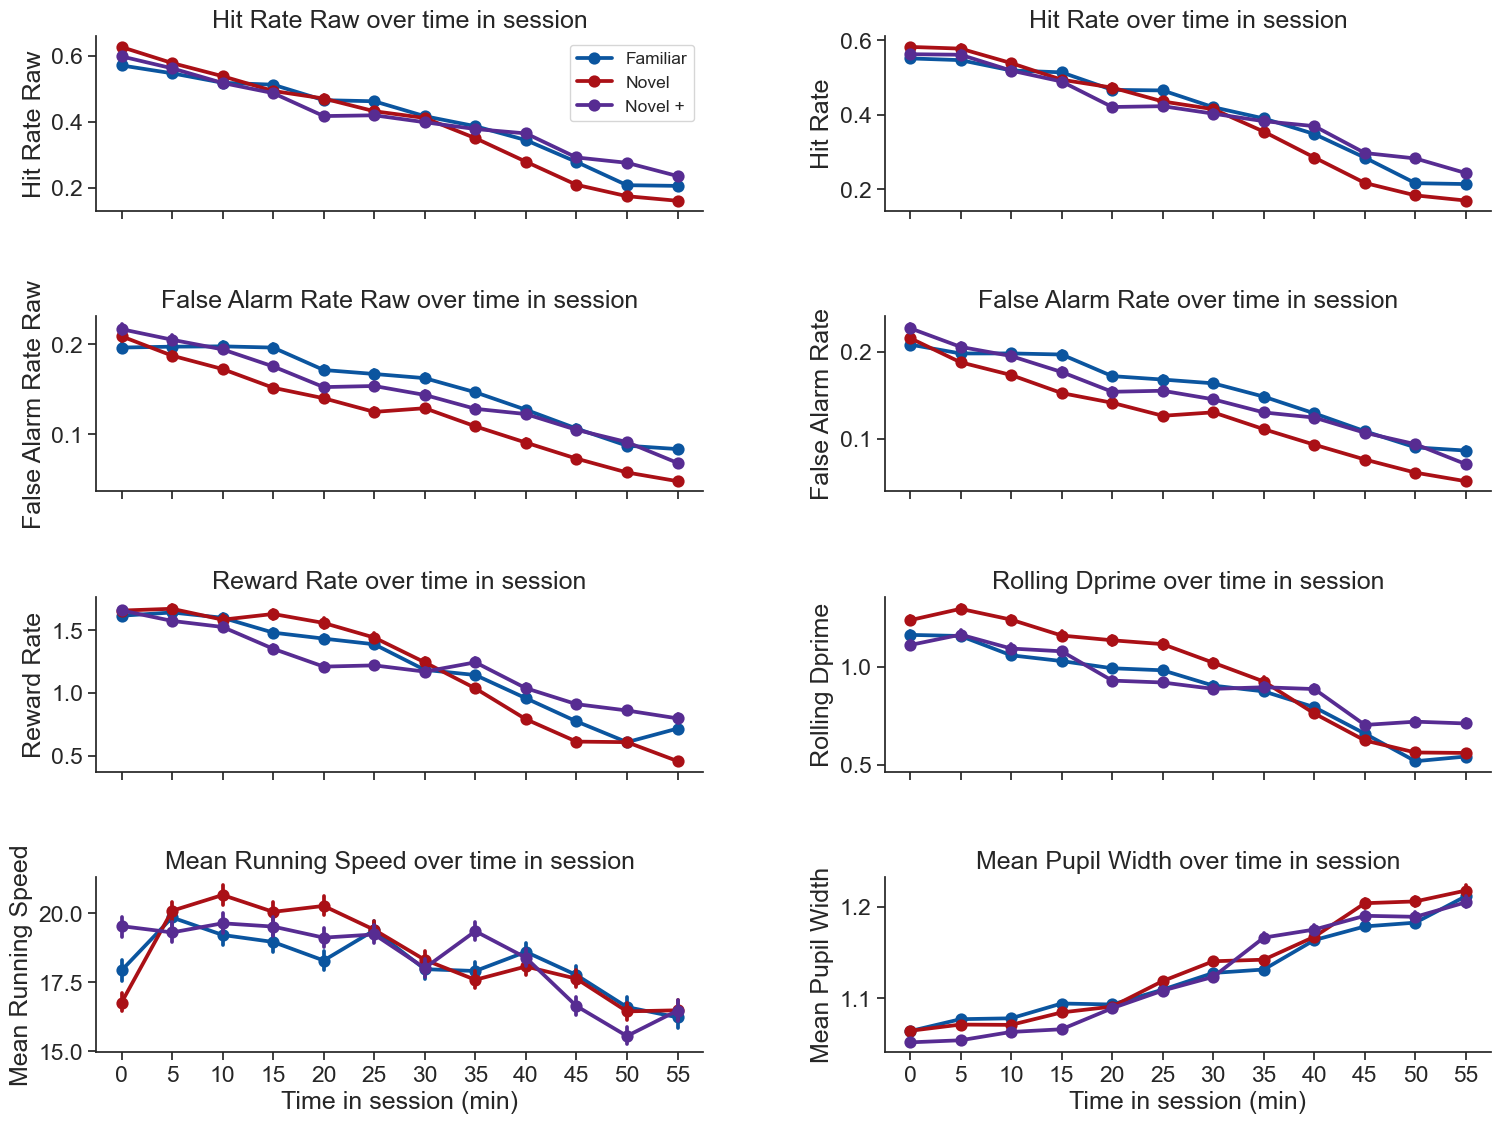

In [30]:
# all rolling metrics over the session, by experience (adds running speed / pupil if present)
metrics = [m for m in ['hit_rate_raw', 'hit_rate', 'false_alarm_rate_raw', 'false_alarm_rate',
                       'reward_rate', 'rolling_dprime', 'mean_running_speed', 'mean_pupil_width']
           if m in rolling_df.columns]
ncols = 2
nrows = int(np.ceil(len(metrics) / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(18, 3.3 * nrows), sharex=True)
ax = ax.ravel()
experience_level_colors = utils.get_experience_level_colors()

bin_size = 60 * 5  # seconds -> 5-min bins
data = rolling_df.reset_index(drop=True).copy()
data = data[data['time_in_session'] < 3600]
data['time_bin'] = ((data['time_in_session'] // bin_size) * bin_size / 60).astype(int)

for i, metric in enumerate(metrics):
    ax[i] = sns.pointplot(data=data, x='time_bin', y=metric, hue='experience_level',
                          palette=experience_level_colors, ax=ax[i])
    ax[i].set_xlabel('Time in session (min)')
    ax[i].set_title(metric.replace('_', ' ').title() + ' over time in session')
    ax[i].set_ylabel(metric.replace('_', ' ').title())
    if ax[i].get_legend() is not None:
        ax[i].get_legend().remove()
for k in range(len(metrics), len(ax)):
    ax[k].axis('off')
ax[0].legend(fontsize='x-small', title_fontsize='x-small')
fig.subplots_adjust(hspace=0.6, wspace=0.3)
plt.show()

## Rolling performance metrics — SDK (for comparison)

The SDK's trial-based rolling performance (`dataset.get_rolling_performance_df()`), loaded from the saved
`{mouse_id}_rolling_performance_df.csv` files. The SDK rolling is per **trial** and the saved file has no
per-trial time, so this is plotted over **trial number within the session** rather than minutes — the
trajectory is comparable in spirit to the stimulus-based plot above, but the x-axis differs.

In [31]:
sdk_rolling_dir = os.path.join(loading.get_analysis_files_dir(), 'rolling_performance_dfs')
sdk_rolling_df = pd.DataFrame()
missing = []
for mouse_id in platform_experiments.mouse_id.unique():
    fp = os.path.join(sdk_rolling_dir, str(mouse_id) + '_rolling_performance_df.csv')
    try:
        d = pd.read_csv(fp, index_col=0)
        d['mouse_id'] = mouse_id
        sdk_rolling_df = pd.concat((sdk_rolling_df, d))
    except Exception:
        missing.append(mouse_id)
print(len(sdk_rolling_df.mouse_id.unique()), 'mice loaded; missing', len(missing))

# the saved SDK rolling df has ophys_experiment_id but not experience_level -> merge it in
if 'experience_level' not in sdk_rolling_df.columns and 'ophys_experiment_id' in sdk_rolling_df.columns:
    sdk_rolling_df = sdk_rolling_df.merge(
        platform_experiments[['experience_level']],
        left_on='ophys_experiment_id', right_index=True, how='left')

# within-session trial number (proxy x-axis: the SDK rolling has no per-trial time in the saved file)
session_key = 'ophys_session_id' if 'ophys_session_id' in sdk_rolling_df.columns else 'mouse_id'
sdk_rolling_df['trial_number'] = sdk_rolling_df.groupby(session_key).cumcount()
print('columns:', list(sdk_rolling_df.columns))
sdk_rolling_df.head()

66 mice loaded; missing 0
columns: ['reward_rate', 'hit_rate_raw', 'hit_rate', 'false_alarm_rate_raw', 'false_alarm_rate', 'rolling_dprime', 'auto_rewarded', 'is_change', 'change_time', 'response_latency', 'ophys_experiment_id', 'ophys_session_id', 'mouse_id', 'experience_level', 'trial_number']


,reward_rate,hit_rate_raw,hit_rate,false_alarm_rate_raw,false_alarm_rate,rolling_dprime,auto_rewarded,is_change,change_time,response_latency,ophys_experiment_id,ophys_session_id,mouse_id,experience_level,trial_number
trials_id,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,795073741,794918442,412036,Familiar,0
1,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,795073741,794918442,412036,Familiar,1
2,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,795073741,794918442,412036,Familiar,2
3,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,795073741,794918442,412036,Familiar,3
4,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,795073741,794918442,412036,Familiar,4


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_44119/367410731.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), fontsize=12, rotation=0)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_44119/367410731.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i-1].set_xticklabels(ax[i-1].get_xticklabels(), fontsize=12, rotation=0)


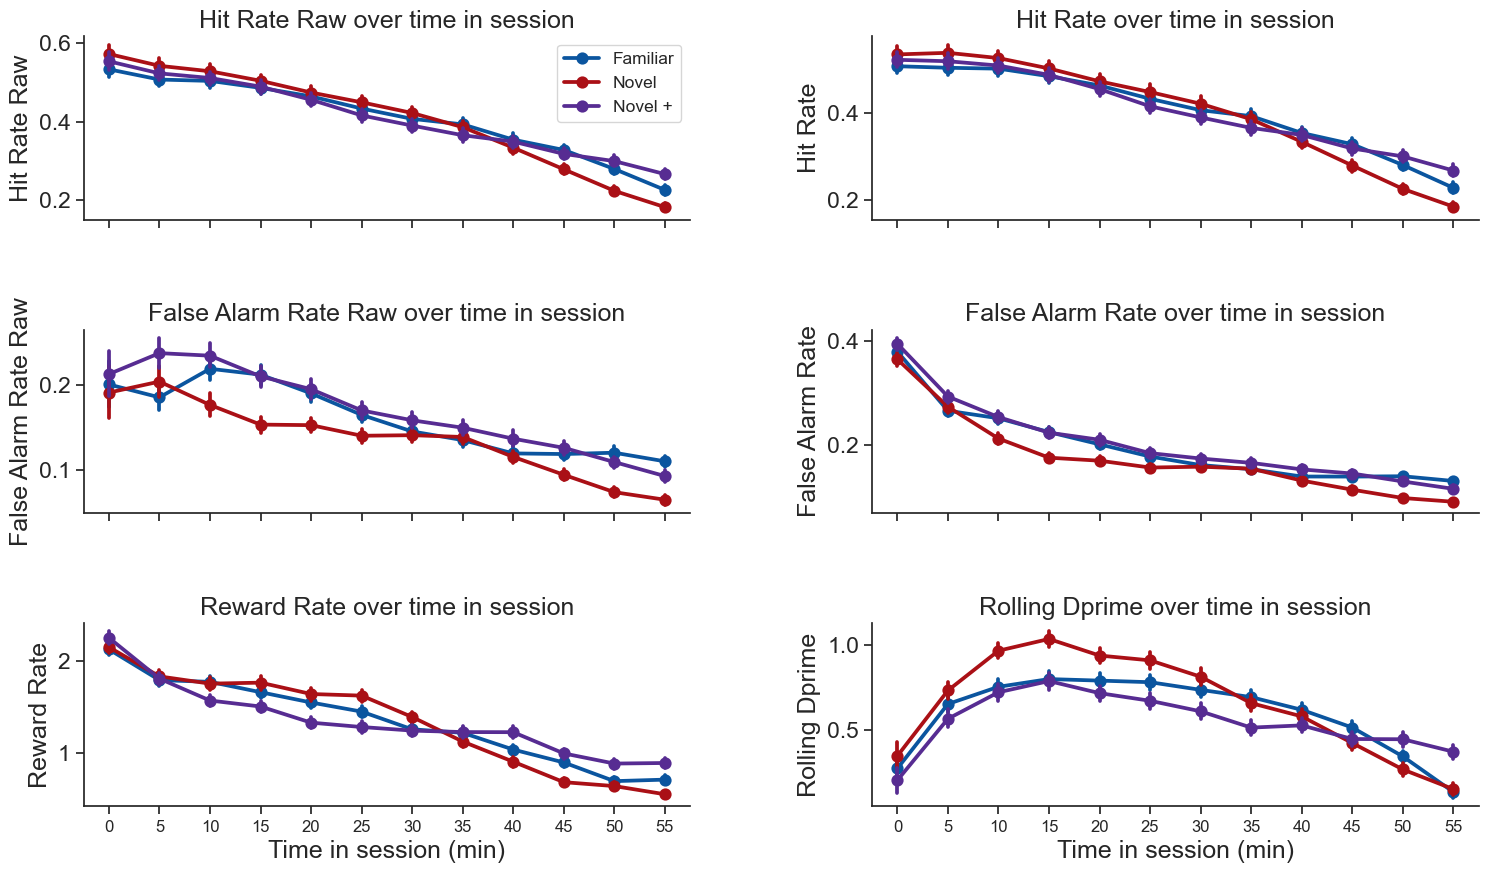

In [32]:
fig, ax = plt.subplots(3, 2, figsize=(18, 10), sharex=True)
ax = ax.ravel()
for i, metric in enumerate([ 'hit_rate_raw', 'hit_rate',
               'false_alarm_rate_raw', 'false_alarm_rate', 
               'reward_rate', 'rolling_dprime']):

    data = sdk_rolling_df.reset_index(drop=True)
    # data = data[(data.trials_id>10) & (data.auto_rewarded==False)]
    data['change_time'] = (data['change_time'] - data.groupby('ophys_experiment_id')['change_time'].transform('min'))
    data = data[data.change_time < 3600]   # adjust window as needed

    # 30-second bins: 0-29, 30-59, ...
    bin_size = 60 * 5 # in seconds
    data['time_bin'] = ((data['change_time'] // bin_size) * bin_size) / 60
    data['time_bin'] = [int(x) for x in data['time_bin']]
    # data['time_bin'] = ((data['change_time'] // bin_size) * bin_size).astype(int)
    experience_level_colors = utils.get_experience_level_colors()
    ax[i] = sns.pointplot(data=data, x='time_bin', y=metric,
                       hue='experience_level', palette=experience_level_colors, ax=ax[i])

    
    ax[i].set_xlabel('Time in session (min)')
    ax[i].set_title(metric.replace('_', ' ').title() + ' over time in session')
    ax[i].set_ylabel(metric.replace('_', ' ').title())
    ax[i].get_legend().remove()
ax[0].legend(fontsize='x-small', title_fontsize='x-small')
ax[i].set_xticklabels(ax[i].get_xticklabels(), fontsize=12, rotation=0)
ax[i-1].set_xticklabels(ax[i-1].get_xticklabels(), fontsize=12, rotation=0)

fig.subplots_adjust(hspace=0.6, wspace=0.3)

## Session-average metrics

Per session: hit rate, could-change FA rate, and d-prime over the could-change opportunities (whole
session and engaged-only), plus mean / peak rolling d-prime and fraction engaged. Engaged = stimulus-based
`engagement_state == 'engaged'`.

In [33]:
def _opportunity_metrics(sp):
    go = sp[(sp.auto_rewarded == False) & (sp.could_change == True) & (sp.is_change == True)]
    catch = sp[(sp.auto_rewarded == False) & (sp.could_change == True) & (sp.is_change == False)]
    hits = go[go['licked'].astype(bool)]
    return pd.Series({
        'hit_rate': go['licked'].mean(),
        'fa_rate': catch['licked'].mean(),  # could-change-based false alarm rate
        'dprime': vbu.dprime(go_trials=go['licked'], catch_trials=catch['licked'], limits=True),
        'lick_latency': hits['lick_latency'].astype(float).mean() if 'lick_latency' in sp.columns else np.nan,
    })

def session_opportunity_stats(sp):
    whole = _opportunity_metrics(sp)
    engaged = _opportunity_metrics(sp[sp.engagement_state == 'engaged']).add_suffix('_engaged')
    opportunities = sp[(sp.auto_rewarded == False) & (sp.could_change == True)]
    frac = pd.Series({'fraction_engaged': (opportunities['engagement_state'] == 'engaged').mean()})
    return pd.concat([whole, engaged, frac])

def session_rolling_stats(roll):
    eng = roll.loc[roll['engagement_state'] == 'engaged', 'rolling_dprime']
    return pd.Series({
        'mean_dprime': roll['rolling_dprime'].mean(),
        'max_dprime': roll['rolling_dprime'].max(),
        'mean_dprime_engaged': eng.mean(),
        'max_dprime_engaged': eng.max(),
    })

opp_stats = stim_behavior_response_df.groupby('behavior_session_id').apply(session_opportunity_stats)
roll_stats = rolling_df.groupby('behavior_session_id').apply(session_rolling_stats)

stats = opp_stats.join(roll_stats).reset_index().merge(session_meta, on='behavior_session_id', how='left')
print(stats.shape[0], 'sessions ;', stats.mouse_id.nunique(), 'mice')
stats.head()

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))


202 sessions ; 66 mice


,behavior_session_id,hit_rate,fa_rate,dprime,lick_latency,hit_rate_engaged,fa_rate_engaged,dprime_engaged,lick_latency_engaged,fraction_engaged,mean_dprime,max_dprime,mean_dprime_engaged,max_dprime_engaged,mouse_id,experience_level,cell_type
0,794071128,0.548148,0.423333,0.314357,0.461854,NaN,NaN,NaN,NaN,0.000000,0.306664,1.281552,NaN,NaN,412366,Familiar,Excitatory
1,794673280,0.510490,0.361919,0.379631,0.522412,0.947368,0.315789,2.099362,0.471803,0.068592,0.390589,1.956041,0.656339,1.824839,412366,Novel,Excitatory
2,794968300,0.724490,0.358531,0.958619,0.505553,0.827586,0.259740,1.588816,0.483413,0.188948,1.034268,1.861070,1.039057,1.365925,412036,Familiar,Vip Inhibitory
3,795742990,0.452381,0.185829,0.773724,0.521876,0.810127,0.252874,1.543837,0.523518,0.354906,1.012426,2.173843,1.539885,2.173843,412036,Novel,Vip Inhibitory
4,796031509,0.554054,0.363775,0.484298,0.537953,0.750000,0.275362,1.271164,0.540305,0.115528,0.498792,1.572007,0.677448,0.963625,412366,Novel +,Excitatory


## Session metrics by experience, across mice

All session-level metrics in one grid: **top row = full session, bottom row = engaged portion**, columns = metrics. Reuses `plot_behavior_metric_by_experience` (per-mouse points + across-experience stats). `fraction_engaged` has no full/engaged split, so its bottom cell is blank.

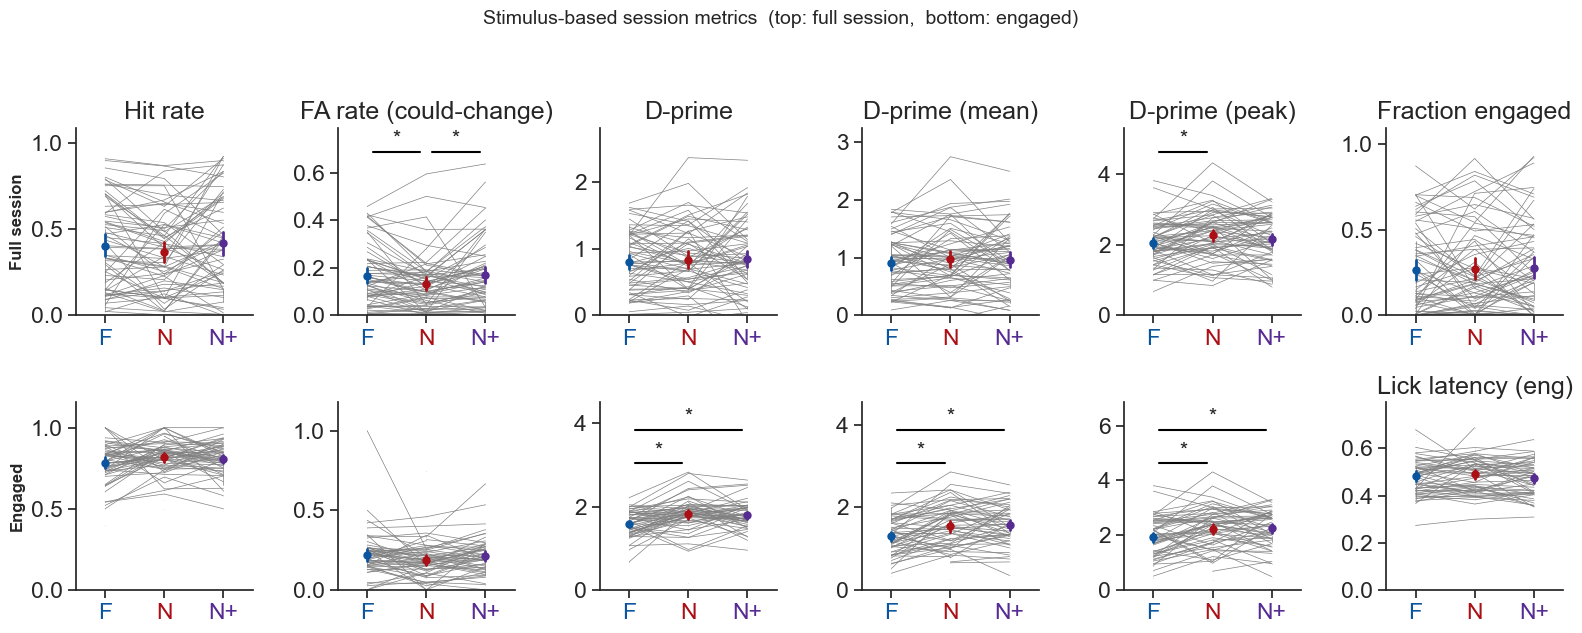

In [34]:
def plot_session_metric_grid(df, cols, suptitle):
    """2-row grid: top = full session, bottom = engaged.
    cols = list of (top_col, bottom_col_or_None, top_label[, bottom_label]); the optional 4th
    element labels the bottom panel when it is a DIFFERENT metric (e.g. lick latency under fraction engaged)."""
    cols = [c for c in cols if c[0] in df.columns]
    ncols = len(cols)
    fig, axes = plt.subplots(2, ncols, figsize=(2.7 * ncols, 6.4))
    for j, c in enumerate(cols):
        top, bottom, tlabel = c[0], c[1], c[2]
        blabel = c[3] if len(c) > 3 else ''
        ppf.plot_behavior_metric_by_experience(
            df, top, title=tlabel, ylabel='', ax=axes[0][j],
            show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
        if bottom is not None and bottom in df.columns:
            ppf.plot_behavior_metric_by_experience(
                df, bottom, title=blabel, ylabel='', ax=axes[1][j],
                show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
        else:
            axes[1][j].axis('off')
    axes[0][0].set_ylabel('Full session', fontsize=12, fontweight='bold')
    axes[1][0].set_ylabel('Engaged', fontsize=12, fontweight='bold')
    fig.suptitle(suptitle, y=1.0, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# stimulus-based session metrics. Last column: fraction engaged (top) with engaged lick latency
# placed in the cell directly beneath it (bottom / engaged row).
stim_cols = [
    ('hit_rate', 'hit_rate_engaged', 'Hit rate'),
    ('fa_rate', 'fa_rate_engaged', 'FA rate (could-change)'),
    ('dprime', 'dprime_engaged', 'D-prime'),
    ('mean_dprime', 'mean_dprime_engaged', 'D-prime (mean)'),
    ('max_dprime', 'max_dprime_engaged', 'D-prime (peak)'),
    ('fraction_engaged', 'lick_latency_engaged', 'Fraction engaged', 'Lick latency (eng)'),
]
plot_session_metric_grid(stats, stim_cols,
                         'Stimulus-based session metrics  (top: full session,  bottom: engaged)')


## Session-average metrics — SDK (for comparison)

SDK metrics from `sdk_all_sessions.h5` (`get_performance_metrics`), plotted by experience with the same
function. Note the definitional differences from the stimulus-based versions above: the SDK uses the
sparse single-catch-flash false-alarm rate and a trial-based engagement state, and its `mean_*` metrics
are means of the rolling trial-based signal. This is where to look for the d-prime-peak experience
differences (`max_dprime` whole-session vs engaged).

In [35]:
behavior_metrics_dir = loading.get_performance_metrics_dir()
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
behavior_stats_sdk = behavior_stats_sdk.reset_index().merge(session_meta, on='behavior_session_id', how='left')
behavior_stats_sdk = behavior_stats_sdk[
    behavior_stats_sdk.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# SDK fraction engaged (trial-based): engaged trials / all trials
if {'engaged_trial_count', 'trial_count'}.issubset(behavior_stats_sdk.columns):
    behavior_stats_sdk['fraction_engaged'] = behavior_stats_sdk['engaged_trial_count'] / behavior_stats_sdk['trial_count']
print(behavior_stats_sdk.shape[0], 'sessions ;', behavior_stats_sdk.mouse_id.nunique(), 'mice')
behavior_stats_sdk.head()

202 sessions ; 66 mice


,behavior_session_id,trial_count,go_trial_count,catch_trial_count,hit_trial_count,miss_trial_count,false_alarm_trial_count,correct_reject_trial_count,auto_reward_count,earned_reward_count,...,mean_false_alarm_rate_uncorrected,mean_false_alarm_rate_engaged,mean_dprime,mean_dprime_engaged,max_dprime,max_dprime_engaged,mouse_id,experience_level,cell_type,fraction_engaged
42,794968300,1051,100,12,71,29,3,9,0,71,...,0.246949,0.303470,1.203225,1.154542,1.843439,1.764152,412036.0,Familiar,Vip Inhibitory,0.127498
43,795742990,692,214,29,95,119,6,23,0,95,...,0.216970,0.267693,0.937126,1.322297,1.756979,1.756979,412036.0,Novel,Vip Inhibitory,0.518786
45,796251270,739,197,28,122,75,5,23,0,122,...,0.288616,0.304427,1.414170,1.332070,2.236554,2.057484,412036.0,Novel +,Vip Inhibitory,0.625169
70,794071128,757,135,20,68,67,11,9,0,68,...,0.532751,0.577551,-0.200187,-0.326479,0.207719,-0.245006,412366.0,Familiar,Excitatory,0.062087
71,794673280,749,144,22,69,75,8,14,0,69,...,0.343804,0.298433,0.307660,0.429923,0.728893,0.728893,412366.0,Novel,Excitatory,0.105474


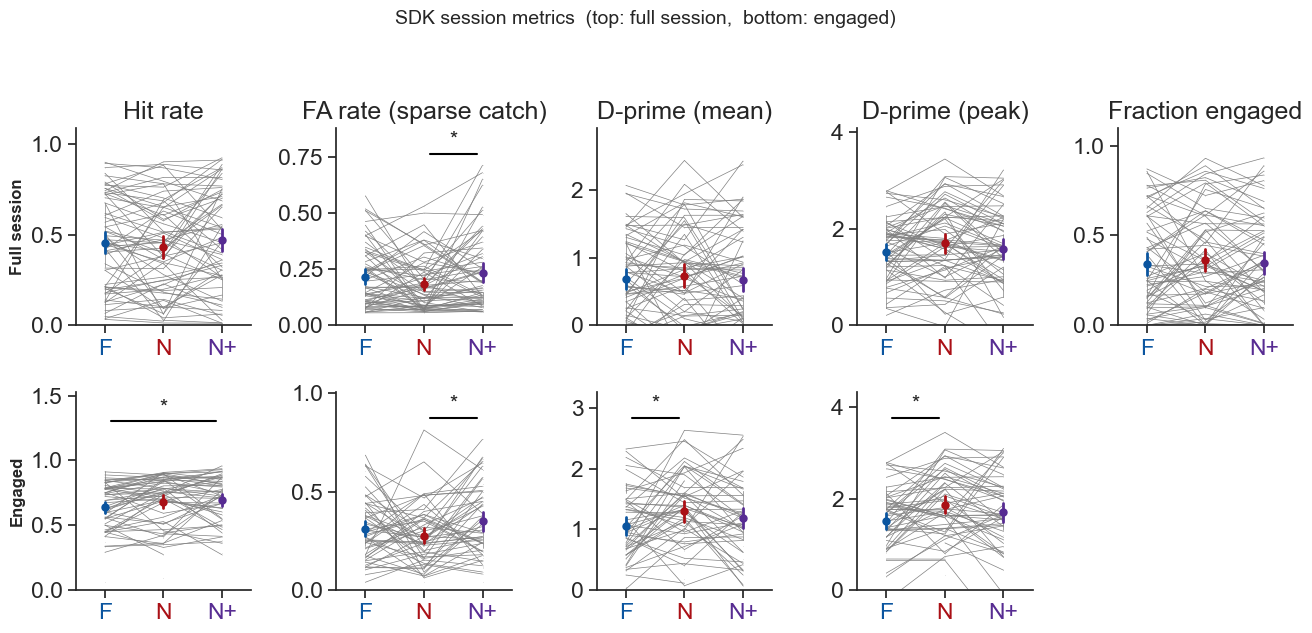

In [36]:
def plot_session_metric_grid(df, cols, suptitle):
    """2-row grid: top = full session, bottom = engaged.
    cols = list of (top_col, bottom_col_or_None, top_label[, bottom_label]); the optional 4th
    element labels the bottom panel when it is a DIFFERENT metric (e.g. lick latency under fraction engaged)."""
    cols = [c for c in cols if c[0] in df.columns]
    ncols = len(cols)
    fig, axes = plt.subplots(2, ncols, figsize=(2.7 * ncols, 6.4))
    for j, c in enumerate(cols):
        top, bottom, tlabel = c[0], c[1], c[2]
        blabel = c[3] if len(c) > 3 else ''
        ppf.plot_behavior_metric_by_experience(
            df, top, title=tlabel, ylabel='', ax=axes[0][j],
            show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
        if bottom is not None and bottom in df.columns:
            ppf.plot_behavior_metric_by_experience(
                df, bottom, title=blabel, ylabel='', ax=axes[1][j],
                show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
        else:
            axes[1][j].axis('off')
    axes[0][0].set_ylabel('Full session', fontsize=12, fontweight='bold')
    axes[1][0].set_ylabel('Engaged', fontsize=12, fontweight='bold')
    fig.suptitle(suptitle, y=1.0, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# SDK session metrics (same layout) for comparison. SDK has no lick latency, so the fraction-engaged
# column's bottom cell stays blank.
sdk_cols = [
    ('mean_hit_rate', 'mean_hit_rate_engaged', 'Hit rate'),
    ('mean_false_alarm_rate', 'mean_false_alarm_rate_engaged', 'FA rate (sparse catch)'),
    ('mean_dprime', 'mean_dprime_engaged', 'D-prime (mean)'),
    ('max_dprime', 'max_dprime_engaged', 'D-prime (peak)'),
    ('fraction_engaged', None, 'Fraction engaged'),
]
plot_session_metric_grid(behavior_stats_sdk, sdk_cols,
                         'SDK session metrics  (top: full session,  bottom: engaged)')


## Response rate by flash type

Response rate = fraction of flashes with a lick, computed directly from `stimulus_behavior_response_df`
by subsetting on the relevant column and taking the mean of `licked`, for: **change** (`is_change`),
**could_change** (`could_change`), **omission** (`omitted`), and **post-omission** (`post_omitted`)
flashes. One value per session; plotted by experience level.

In [37]:
def _first_present(df, names):
    return next((n for n in names if n in df.columns), None)

flash_types = [
    ('change',        _first_present(stim_behavior_response_df, ['is_change'])),
    ('could_change',  _first_present(stim_behavior_response_df, ['could_change'])),
    ('omission',      _first_present(stim_behavior_response_df, ['omitted', 'is_omitted'])),
    ('post-omission', _first_present(stim_behavior_response_df, ['post_omitted', 'post_omission'])),
]

recs = []
for label, col in flash_types:
    if col is None:
        print('skipping', label, '- no matching column')
        continue
    sub = stim_behavior_response_df[stim_behavior_response_df[col] == True]
    g = sub.groupby('behavior_session_id')['licked'].mean().rename('response_rate').reset_index()
    g['trial_type'] = label
    recs.append(g)

response_rate_df = pd.concat(recs, ignore_index=True).merge(
    session_meta[['behavior_session_id', 'experience_level', 'mouse_id']],
    on='behavior_session_id', how='left')
print(response_rate_df.groupby('trial_type')['response_rate'].median().round(3).to_dict())
response_rate_df.head()

{'change': 0.39, 'could_change': 0.192, 'omission': 0.16, 'post-omission': 0.274}


,behavior_session_id,response_rate,trial_type,experience_level,mouse_id
0,794071128,0.548148,change,Familiar,412366
1,794673280,0.513889,change,Novel,412366
2,794968300,0.720000,change,Familiar,412036
3,795742990,0.462617,change,Novel,412036
4,796031509,0.560000,change,Novel +,412366


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_44119/3496359194.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


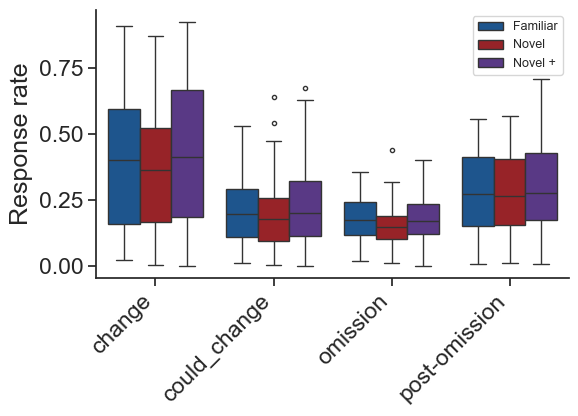

In [38]:
# boxplot: x = flash type, hue = experience level (matches the Figure 2 panel H style)
order = [label for label, col in flash_types if col is not None]
hue_order = [e for e in utils.get_new_experience_levels()
             if e in response_rate_df['experience_level'].unique()]
colors = utils.get_experience_level_colors()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=response_rate_df, x='trial_type', y='response_rate',
            hue='experience_level', order=order, hue_order=hue_order,
            palette=colors[:len(hue_order)], fliersize=3, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Response rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

## D-prime versions by cohort and cell type

All d-prime variants (`dprime`, `dprime_engaged`, `mean_dprime`, `mean_dprime_engaged`, `max_dprime`,
`max_dprime_engaged`) plotted by experience level, split by **cohort** (`project_code`) and by **cell type**.
Rows = group, columns = d-prime version; each panel is the metric by experience (per-mouse points).

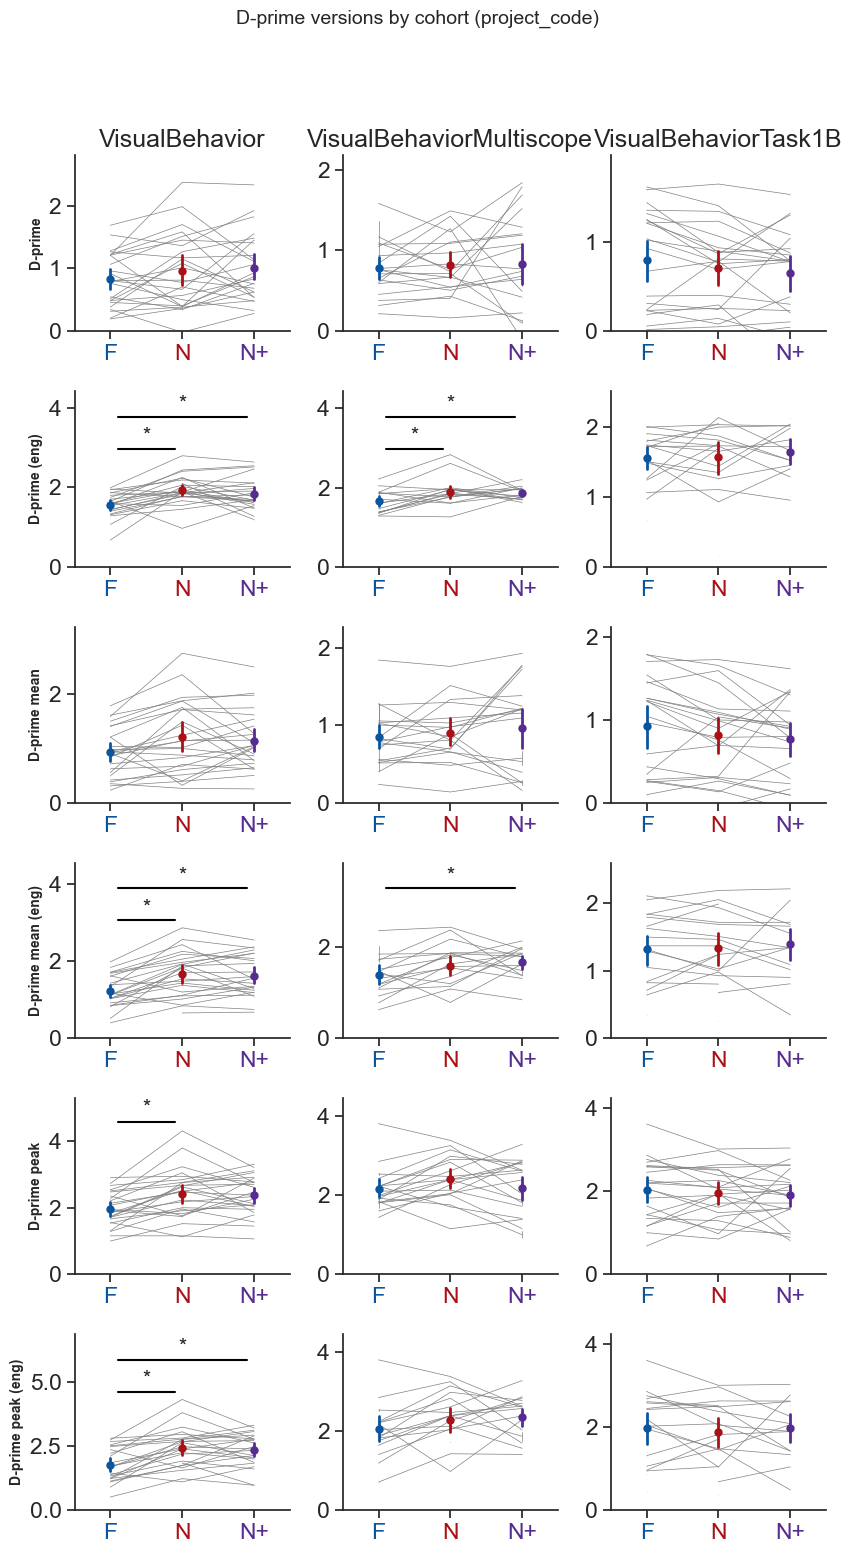

In [39]:
# bring project_code (cohort) onto the session stats
stats_grouped = stats.merge(
    platform_experiments[['behavior_session_id', 'project_code']].drop_duplicates('behavior_session_id'),
    on='behavior_session_id', how='left')

dprime_metrics = [
    ('dprime', 'D-prime'),
    ('dprime_engaged', 'D-prime (eng)'),
    ('mean_dprime', 'D-prime mean'),
    ('mean_dprime_engaged', 'D-prime mean (eng)'),
    ('max_dprime', 'D-prime peak'),
    ('max_dprime_engaged', 'D-prime peak (eng)'),
]

def plot_dprime_versions_by_group(df, group_col, metrics, suptitle, group_order=None):
    # rows = d-prime version, columns = group (cohorts / cell types side by side)
    groups = group_order if group_order is not None else sorted(df[group_col].dropna().unique())
    groups = [g for g in groups if (df[group_col] == g).any()]
    nrows, ncols = len(metrics), len(groups)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.9 * ncols, 2.6 * nrows), squeeze=False)
    for r, (metric, label) in enumerate(metrics):
        for c, grp in enumerate(groups):
            ax = axes[r][c]
            sub = df[df[group_col] == grp]
            if metric not in sub.columns or sub[metric].notna().sum() < 2:
                ax.axis('off')
                continue
            try:
                ppf.plot_behavior_metric_by_experience(
                    sub, metric, title=(str(grp) if r == 0 else ''), ylabel='', ax=ax,
                    show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
            except Exception as e:
                ax.axis('off')
                print('skipped', grp, metric, repr(e)[:80])
        axes[r][0].set_ylabel(label, fontsize=10, fontweight='bold')
    fig.suptitle(suptitle, y=1.0, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# by cohort (cohorts side by side as columns)
plot_dprime_versions_by_group(stats_grouped, 'project_code', dprime_metrics,
                              'D-prime versions by cohort (project_code)')

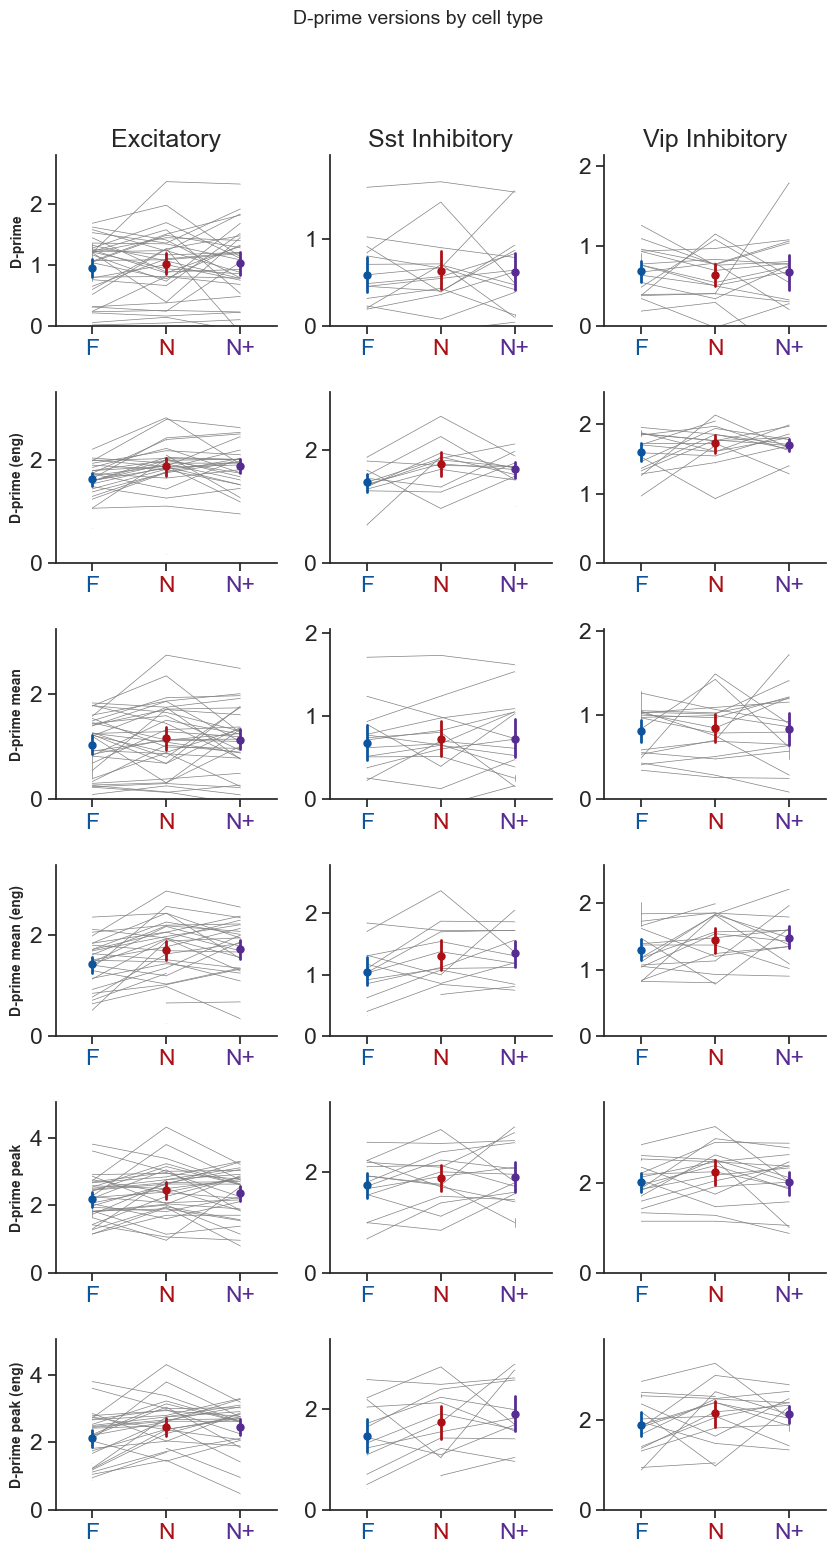

In [40]:
# by cell type (ordered Excitatory / Sst / Vip)
cell_type_order = [ct for ct in utils.get_cell_types() if (stats_grouped['cell_type'] == ct).any()]
plot_dprime_versions_by_group(stats_grouped, 'cell_type', dprime_metrics,
                              'D-prime versions by cell type', group_order=cell_type_order)

## Engagement by reward-rate threshold (1 vs 2)

Define engaged as the stimulus-based **reward rate > threshold** (rewards/min) from the rolling stim df.
RR > 2 is the standard engagement definition; RR > 1 is more permissive (larger engaged fraction). Compares
hit rate, FA rate, and d-prime for the full session vs engaged (RR > 2) vs engaged (RR > 1), plus the
fraction of could-change opportunities engaged under each threshold.

In [41]:
def _rr_threshold_stats(roll):
    out = {}
    for name, sub in [('full', roll),
                      ('rr2', roll[roll['reward_rate'] > 2]),
                      ('rr1', roll[roll['reward_rate'] > 1])]:
        go = sub[sub['is_change'] == True]
        catch = sub[sub['is_change'] == False]
        out['hit_rate_' + name] = go['licked'].mean()
        out['fa_rate_' + name] = catch['licked'].mean()
        out['dprime_' + name] = vbu.dprime(go_trials=go['licked'], catch_trials=catch['licked'], limits=True)
    out['fraction_engaged_rr2'] = (roll['reward_rate'] > 2).mean()
    out['fraction_engaged_rr1'] = (roll['reward_rate'] > 1).mean()
    return pd.Series(out)

rr_stats = (rolling_df.groupby('behavior_session_id').apply(_rr_threshold_stats).reset_index()
            .merge(session_meta, on='behavior_session_id', how='left'))
print('median fraction engaged:  reward rate > 2 = %.3f    reward rate > 1 = %.3f'
      % (rr_stats['fraction_engaged_rr2'].median(), rr_stats['fraction_engaged_rr1'].median()))
rr_stats.head()

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/utilities.py:542: RuntimeWarning: invalid value encountered in subtract
  d_prime = Z(hit_rate.fillna(0)) - Z(fa_rate.fillna(0))


median fraction engaged:  reward rate > 2 = 0.205    reward rate > 1 = 0.557


,behavior_session_id,hit_rate_full,fa_rate_full,dprime_full,hit_rate_rr2,fa_rate_rr2,dprime_rr2,hit_rate_rr1,fa_rate_rr1,dprime_rr1,fraction_engaged_rr2,fraction_engaged_rr1,mouse_id,experience_level,cell_type
0,794071128,0.548148,0.423333,0.314357,NaN,NaN,NaN,0.677419,0.421203,0.659310,0.000000,0.601361,412366,Familiar,Excitatory
1,794673280,0.510490,0.361919,0.379631,0.947368,0.315789,2.099362,0.627660,0.338658,0.741789,0.068592,0.489771,412366,Novel,Excitatory
2,794968300,0.724490,0.358531,0.958619,0.827586,0.259740,1.588816,0.750000,0.315217,1.155605,0.188948,0.798574,412036,Familiar,Vip Inhibitory
3,795742990,0.452381,0.185829,0.773724,0.810127,0.252874,1.543837,0.766129,0.275304,1.323008,0.354906,0.645094,412036,Novel,Vip Inhibitory
4,796031509,0.554054,0.363775,0.484298,0.750000,0.275362,1.271164,0.663636,0.363636,0.771164,0.115528,0.601242,412366,Novel +,Excitatory


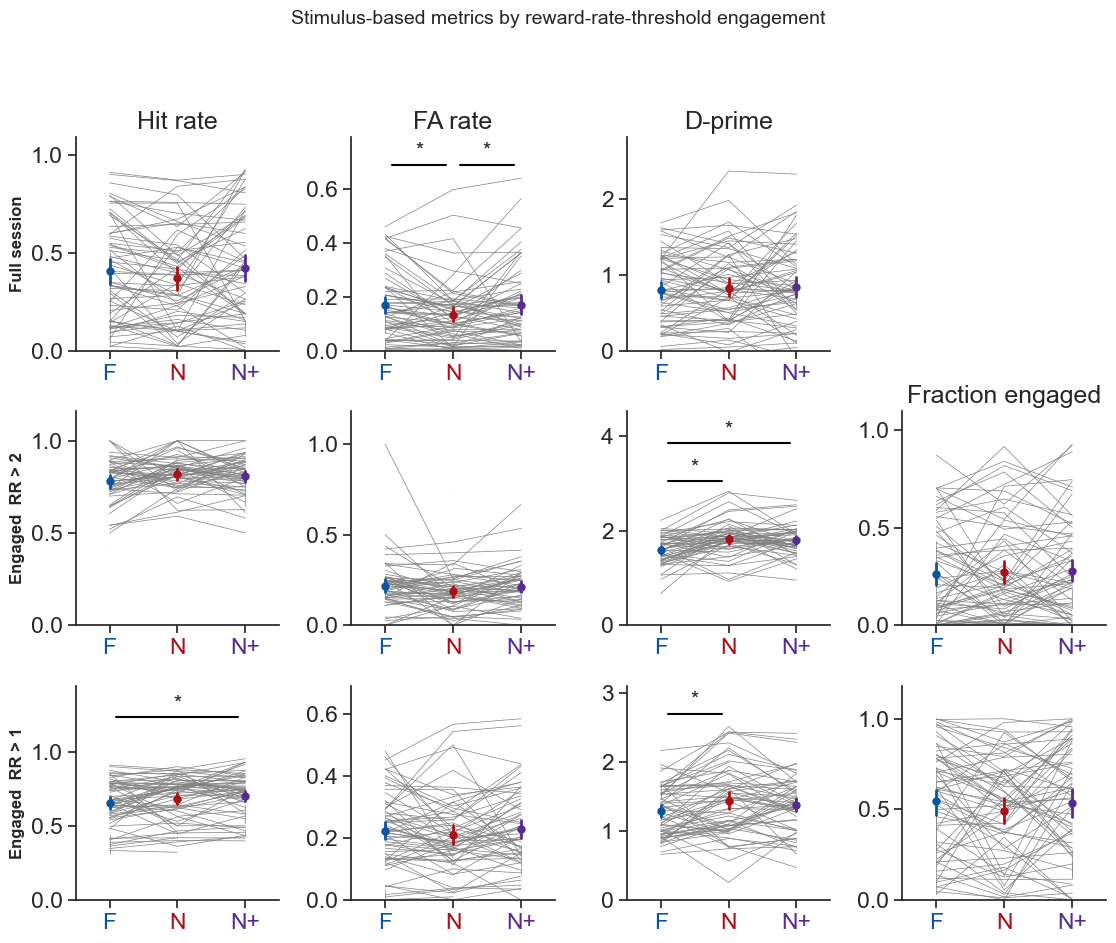

In [42]:
# 3-row grid: full / engaged(RR>2) / engaged(RR>1); columns = hit rate, FA rate, d-prime, fraction engaged
rows = [
    ('Full session',      {'hit_rate': 'hit_rate_full', 'fa_rate': 'fa_rate_full', 'dprime': 'dprime_full', 'fraction': None}),
    ('Engaged  RR > 2',   {'hit_rate': 'hit_rate_rr2',  'fa_rate': 'fa_rate_rr2',  'dprime': 'dprime_rr2',  'fraction': 'fraction_engaged_rr2'}),
    ('Engaged  RR > 1',   {'hit_rate': 'hit_rate_rr1',  'fa_rate': 'fa_rate_rr1',  'dprime': 'dprime_rr1',  'fraction': 'fraction_engaged_rr1'}),
]
col_keys = ['hit_rate', 'fa_rate', 'dprime', 'fraction']
col_labels = ['Hit rate', 'FA rate', 'D-prime', 'Fraction engaged']

fig, axes = plt.subplots(3, 4, figsize=(11.5, 9.5))
for cc, key in enumerate(col_keys):
    first_visible = next((r for r, (_, cm) in enumerate(rows) if cm[key] is not None), 0)
    for r, (rowlabel, cm) in enumerate(rows):
        ax = axes[r][cc]
        metric = cm[key]
        if metric is None or metric not in rr_stats.columns:
            ax.axis('off')
            continue
        ppf.plot_behavior_metric_by_experience(
            rr_stats, metric, title=(col_labels[cc] if r == first_visible else ''), ylabel='',
            ax=ax, show_mice=True, plot_stats=True, stripplot=False, show_ns=False)
for r, (rowlabel, cm) in enumerate(rows):
    axes[r][0].set_ylabel(rowlabel, fontsize=12, fontweight='bold')
fig.suptitle('Stimulus-based metrics by reward-rate-threshold engagement', y=1.0, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Direct comparison: false alarm rate & engagement (stim could-change vs SDK)

Per-session comparison of the two definitions, to confirm *how* and *why* the could-change version
differs from the SDK:
- **FA rate**: stim could-change (every could-change non-change flash is a catch opportunity) vs SDK
  sparse-catch (one designated sham-change flash per catch trial).
- **Engagement**: stim stimulus-level reward-rate>2 (earned, could-change denominator) vs SDK trial-level
  reward-rate>2.
- **Catch sample size**: how many catch opportunities each definition averages over.

In [43]:
def _catch_counts(sp):
    catch = sp[(sp.auto_rewarded == False) & (sp.could_change == True) & (sp.is_change == False)]
    return pd.Series({'n_catch_opportunities': len(catch)})
opp_counts = stim_behavior_response_df.groupby('behavior_session_id').apply(_catch_counts).reset_index()

sdk_cols = ['behavior_session_id', 'mean_false_alarm_rate', 'mean_false_alarm_rate_engaged',
            'fraction_engaged', 'catch_trial_count']
cmp = (stats.merge(behavior_stats_sdk[sdk_cols], on='behavior_session_id', suffixes=('_stim', '_sdk'))
            .merge(opp_counts, on='behavior_session_id'))

print('FA rate (engaged):   stim could-change median = %.3f   SDK sparse-catch median = %.3f'
      % (cmp['fa_rate_engaged'].median(), cmp['mean_false_alarm_rate_engaged'].median()))
print('catch sample size:   stim could-change median = %d      SDK catch trials median = %d   (~%.0fx more)'
      % (cmp['n_catch_opportunities'].median(), cmp['catch_trial_count'].median(),
         cmp['n_catch_opportunities'].median() / max(cmp['catch_trial_count'].median(), 1)))
print('fraction engaged:    stim (stimulus) median = %.3f      SDK (trial) median = %.3f'
      % (cmp['fraction_engaged_stim'].median(), cmp['fraction_engaged_sdk'].median()))
print('correlations: FA r = %.3f ;  fraction_engaged r = %.3f'
      % (cmp[['mean_false_alarm_rate_engaged', 'fa_rate_engaged']].corr().iloc[0, 1],
         cmp[['fraction_engaged_sdk', 'fraction_engaged_stim']].corr().iloc[0, 1]))

FA rate (engaged):   stim could-change median = 0.191   SDK sparse-catch median = 0.271
catch sample size:   stim could-change median = 794      SDK catch trials median = 34   (~23x more)
fraction engaged:    stim (stimulus) median = 0.205      SDK (trial) median = 0.308
correlations: FA r = 0.417 ;  fraction_engaged r = 0.956


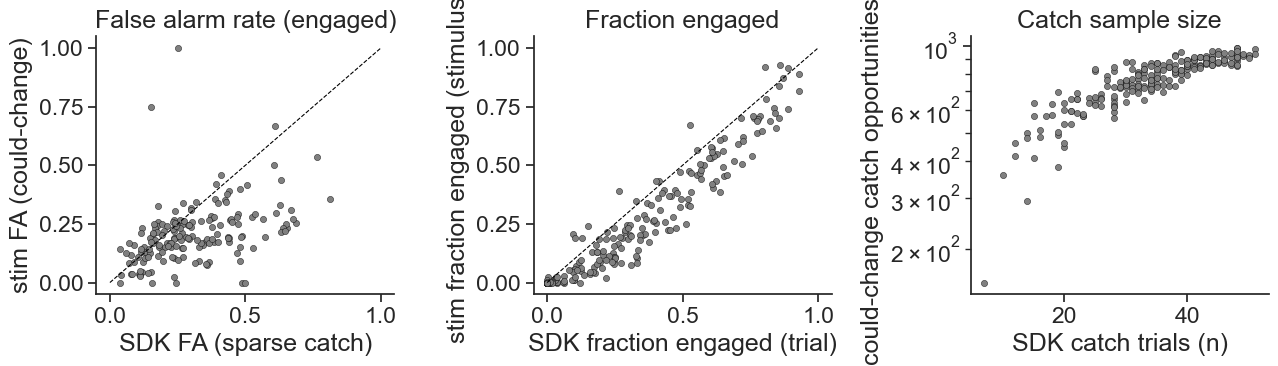

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.scatter(cmp['mean_false_alarm_rate_engaged'], cmp['fa_rate_engaged'], s=20, color='gray', edgecolor='k', lw=0.3)
m = float(np.nanmax([cmp['mean_false_alarm_rate_engaged'].max(), cmp['fa_rate_engaged'].max()]))
ax.plot([0, m], [0, m], 'k--', lw=0.8)
ax.set_xlabel('SDK FA (sparse catch)'); ax.set_ylabel('stim FA (could-change)')
ax.set_title('False alarm rate (engaged)')

ax = axes[1]
ax.scatter(cmp['fraction_engaged_sdk'], cmp['fraction_engaged_stim'], s=20, color='gray', edgecolor='k', lw=0.3)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('SDK fraction engaged (trial)'); ax.set_ylabel('stim fraction engaged (stimulus)')
ax.set_title('Fraction engaged')

ax = axes[2]
ax.scatter(cmp['catch_trial_count'], cmp['n_catch_opportunities'], s=20, color='gray', edgecolor='k', lw=0.3)
ax.set_yscale('log')
ax.set_xlabel('SDK catch trials (n)'); ax.set_ylabel('stim could-change catch opportunities (n, log)')
ax.set_title('Catch sample size')
plt.tight_layout(); plt.show()

**How / why the could-change version changes things**

- **FA scatter sits below y=x** -> the could-change FA is systematically *lower* than the SDK sparse-catch
  FA. The SDK's catch is the single sham-change flash, which occurs at the *expected* change time, so the
  mouse is primed to lick there (high FA). The could-change definition averages over *all* could-change
  flashes -- most nowhere near the expected change time and rarely licked -- pulling the mean FA down.
- **Catch sample size is ~10-50x larger** (right panel, log y) -> far lower variance on the FA estimate,
  the main reason d-prime is cleaner and the small Familiar->Novel difference now reaches significance.
- **Lower FA -> higher d-prime** (d' = Z(hit) - Z(fa)); with the tighter estimate, this is exactly why the
  stim d-prime peaks are higher and the experience differences sharper than the SDK version.
- **Engagement** differs too (stimulus reward-rate>2, earned-only, vs trial-based); the scatter shows how
  the two masks relate per session.

### Direct catch-definition comparison: sham-change flashes vs could-change flashes

The df has `is_sham_change`, which marks the single sham-change flash the SDK uses as its catch. So on the
**same engaged flashes** we can compute the false-alarm rate two ways: on the sham-change flashes (= the SDK
catch) vs on **all** could-change non-change flashes (the stimulus-based definition). If the sham-change FA
is higher and matches the SDK, that is the mechanism made explicit — the sparse SDK catch samples the
high-FA sham flashes, while could-change averages those in with many lower-FA flashes.

In [45]:
def _fa_by_catch_def(sp):
    eng = sp[sp.engagement_state == 'engaged']
    cc = eng[(eng.auto_rewarded == False) & (eng.could_change == True) & (eng.is_change == False)]
    sham = eng[(eng.auto_rewarded == False) & (eng.is_sham_change == True)]
    return pd.Series({'fa_could_change': cc['licked'].mean(),
                      'fa_sham_change': sham['licked'].mean(),
                      'n_could_change': len(cc),
                      'n_sham_change': len(sham)})

fa_compare = (stim_behavior_response_df.groupby('behavior_session_id').apply(_fa_by_catch_def).reset_index()
              .merge(session_meta[['behavior_session_id', 'experience_level', 'mouse_id']], on='behavior_session_id', how='left')
              .merge(behavior_stats_sdk[['behavior_session_id', 'mean_false_alarm_rate_engaged']], on='behavior_session_id', how='left'))

print('median FA:  could-change = %.3f   sham-change (=SDK catch) = %.3f   SDK engaged = %.3f'
      % (fa_compare['fa_could_change'].median(), fa_compare['fa_sham_change'].median(),
         fa_compare['mean_false_alarm_rate_engaged'].median()))
print('median n :  could-change = %d   sham-change = %d   (~%.0fx more opportunities)'
      % (fa_compare['n_could_change'].median(), fa_compare['n_sham_change'].median(),
         fa_compare['n_could_change'].median() / max(fa_compare['n_sham_change'].median(), 1)))
fa_compare.head()

median FA:  could-change = 0.191   sham-change (=SDK catch) = 0.200   SDK engaged = 0.271
median n :  could-change = 148   sham-change = 5   (~30x more opportunities)


,behavior_session_id,fa_could_change,fa_sham_change,n_could_change,n_sham_change,experience_level,mouse_id,mean_false_alarm_rate_engaged
0,794071128,NaN,NaN,0.0,0.0,Familiar,412366,0.577551
1,794673280,0.315789,0.000000,38.0,1.0,Novel,412366,0.298433
2,794968300,0.259740,0.000000,77.0,1.0,Familiar,412036,0.303470
3,795742990,0.252874,0.428571,261.0,7.0,Novel,412036,0.267693
4,796031509,0.275362,0.000000,69.0,1.0,Novel +,412366,0.376497


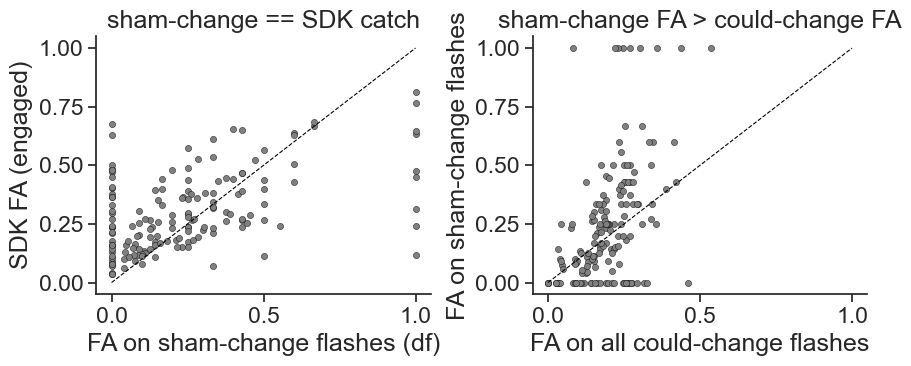

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

ax = axes[0]
ax.scatter(fa_compare['fa_sham_change'], fa_compare['mean_false_alarm_rate_engaged'],
           s=20, color='gray', edgecolor='k', lw=0.3)
m = float(np.nanmax([fa_compare['fa_sham_change'].max(), fa_compare['mean_false_alarm_rate_engaged'].max()]))
ax.plot([0, m], [0, m], 'k--', lw=0.8)
ax.set_xlabel('FA on sham-change flashes (df)'); ax.set_ylabel('SDK FA (engaged)')
ax.set_title('sham-change == SDK catch')

ax = axes[1]
ax.scatter(fa_compare['fa_could_change'], fa_compare['fa_sham_change'],
           s=20, color='gray', edgecolor='k', lw=0.3)
m = float(np.nanmax([fa_compare['fa_could_change'].max(), fa_compare['fa_sham_change'].max()]))
ax.plot([0, m], [0, m], 'k--', lw=0.8)
ax.set_xlabel('FA on all could-change flashes'); ax.set_ylabel('FA on sham-change flashes')
ax.set_title('sham-change FA > could-change FA')
plt.tight_layout(); plt.show()

**Reading it:** left — FA on sham-change flashes tracks the SDK engaged FA along y=x, confirming the
sham-change flash *is* the SDK catch. Right — sham-change FA sits above the diagonal vs could-change FA, so
the SDK catch is a high-FA subset; the broader could-change definition averages it in with many lower-FA
flashes, giving a lower (and, with ~10-50x more opportunities, lower-variance) FA. Same licking behavior,
different sampling of catch opportunities — which is why the stim d-prime is higher and the experience
differences sharper.

### Notes / caveats

- This notebook is **untested pending the regenerated `stimulus_behavior_response_df`** (needs `could_change`
  and the new stimulus-based `engagement_state`/`reward_rate`). The sanity-check cell flags missing columns.
- `fa_rate` here is the **could-change-based** false alarm rate (every could-change non-change flash is a
  catch opportunity), not the SDK sparse-catch definition.
- Engaged metrics use the **stimulus-based** `engagement_state` from the df. Whole-session versions
  (`hit_rate`, `fa_rate`, `dprime`, `mean_dprime`, `max_dprime`) are also in `stats` for comparison.
- To save figures, pass `save_dir=...` to the plotting calls (they accept it, as in figure_2_main).

## With vs. without the auto-rewarded warm-up period

`stim_behavior_response_df` has the auto-rewarded warm-up dropped (see "Drop auto-rewarded warm-up period" above); `stim_behavior_response_df_full` keeps it. Below we recompute the rolling and session-average metrics on both and compare, to show how much the warm-up shifts the results.

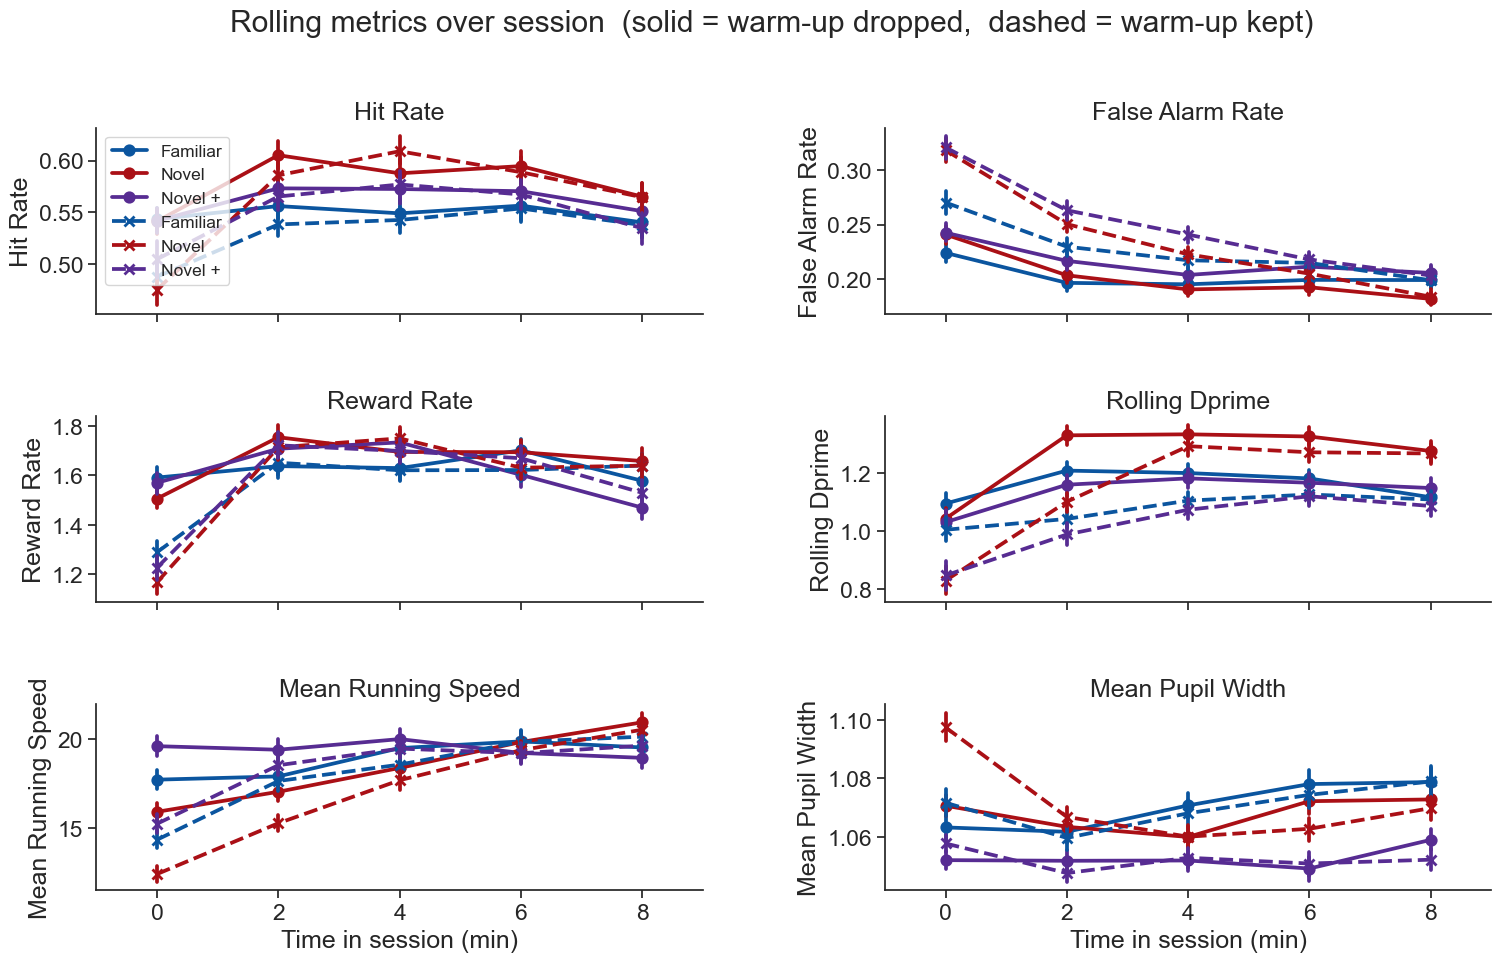

In [50]:
# rolling metrics WITH the warm-up (the trimmed version is the already-computed rolling_df)
roll_with = vbu.get_stimulus_based_rolling_performance_df_for_dataset(
    stim_behavior_response_df_full, session_key='behavior_session_id', response_col='licked').merge(
    session_meta[['behavior_session_id', 'experience_level']], on='behavior_session_id', how='left')
roll_without = rolling_df  # warm-up dropped

metrics = [m for m in ['hit_rate', 'false_alarm_rate', 'reward_rate', 'rolling_dprime',
                       'mean_running_speed', 'mean_pupil_width'] if m in roll_without.columns]
bin_size = 60 * 2  # 5-min bins

def _binned(roll):
    d = roll.reset_index(drop=True).copy()
    d = d[d['time_in_session'] < 60*10]
    d['time_bin'] = ((d['time_in_session'] // bin_size) * bin_size / 60).astype(int)
    return d
d_with, d_without = _binned(roll_with), _binned(roll_without)

colors = utils.get_experience_level_colors()
ncols = 2
nrows = int(np.ceil(len(metrics) / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(18, 3.3 * nrows), sharex=True)
ax = ax.ravel()
for i, metric in enumerate(metrics):
    sns.pointplot(data=d_without, x='time_bin', y=metric, hue='experience_level',
                  palette=colors, ax=ax[i])                                   # solid = warm-up dropped
    sns.pointplot(data=d_with, x='time_bin', y=metric, hue='experience_level',
                  palette=colors, linestyles='--', markers='x', ax=ax[i])     # dashed = warm-up kept
    ax[i].set_xlabel('Time in session (min)')
    ax[i].set_title(metric.replace('_', ' ').title())
    ax[i].set_ylabel(metric.replace('_', ' ').title())
    if ax[i].get_legend() is not None:
        ax[i].get_legend().remove()
for k in range(len(metrics), len(ax)):
    ax[k].axis('off')
ax[0].legend(fontsize='x-small')
fig.suptitle('Rolling metrics over session  (solid = warm-up dropped,  dashed = warm-up kept)', y=1.0)
fig.subplots_adjust(hspace=0.55, wspace=0.3)
plt.show()
